In [84]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import random
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from portfolioenv import PortfolioEnvBBVA
from agent import PPOAgent

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

## 1. Datos — split train / val / test

In [85]:
TICKERS = ['SPY', 'QQQ', 'TLT', 'GLD', 'IEF', 'VNQ', 'EEM', 'USO']


raw    = yf.download(TICKERS, start='2014-01-01', end='2025-12-31',
                     auto_adjust=True, progress=True)
close  = raw['Close'].ffill().dropna()

prices_train = close.loc[:'2020-12-31']
prices_val   = close.loc['2021-01-01':'2022-12-31']
prices_test  = close.loc['2023-01-01':'2024-12-31']

print(f'Train: {len(prices_train)} días  ({prices_train.index[0].date()} → {prices_train.index[-1].date()})')
print(f'Val:   {len(prices_val)}  días  ({prices_val.index[0].date()} → {prices_val.index[-1].date()})')
print(f'Test:  {len(prices_test)} días  ({prices_test.index[0].date()} → {prices_test.index[-1].date()})')

[*********************100%***********************]  8 of 8 completed

Train: 1763 días  (2014-01-02 → 2020-12-31)
Val:   503  días  (2021-01-04 → 2022-12-30)
Test:  502 días  (2023-01-03 → 2024-12-31)


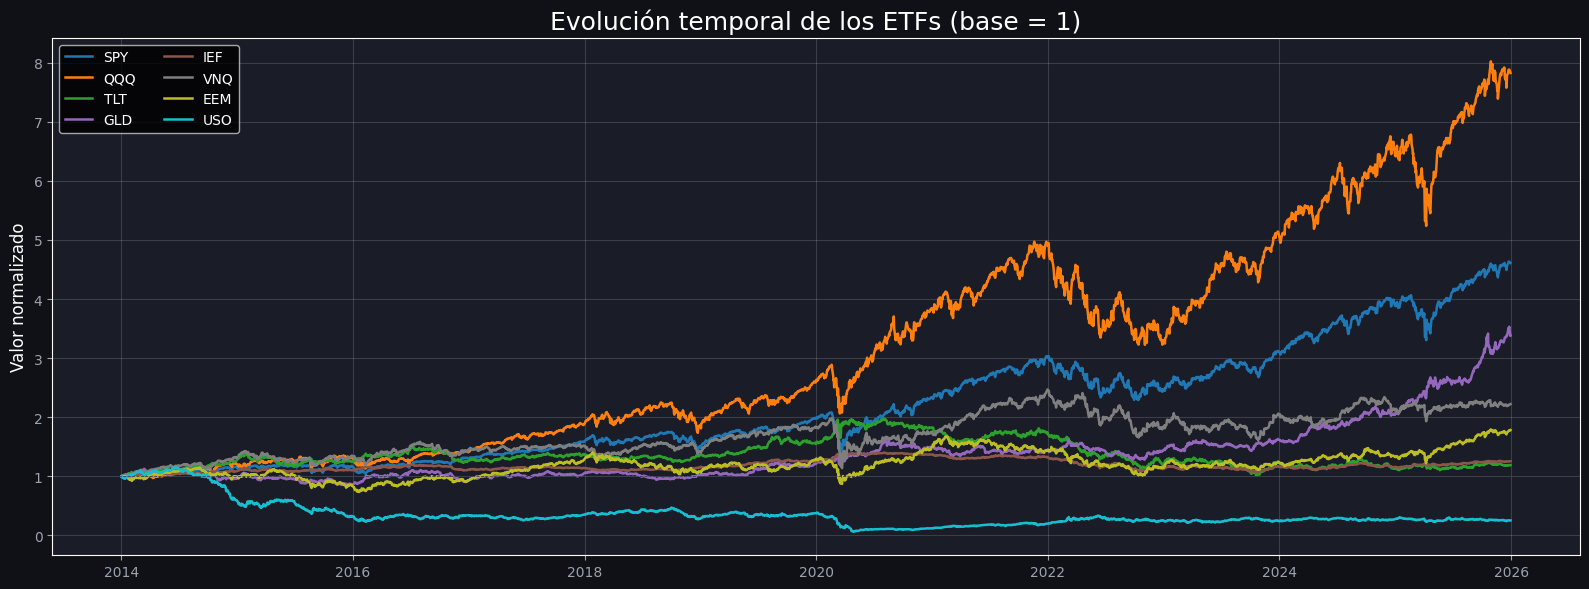

In [86]:
norm_prices = close / close.iloc[0]

fig, ax = plt.subplots(figsize=(16, 6), facecolor='#0F1117')

fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#1A1D27')
cmap = plt.cm.get_cmap('tab10', len(TICKERS))

for i, ticker in enumerate(TICKERS):
    ax.plot(norm_prices.index, norm_prices[ticker], label=ticker, color=cmap(i), linewidth=1.8)
ax.axhline(1, color='#374151', linewidth=0.6, linestyle='--')
ax.set_title('Evolución temporal de los ETFs (base = 1)', color='white', fontsize=18)
ax.set_ylabel('Valor normalizado', color='white', fontsize=12)
ax.grid(alpha=0.15)
ax.legend(loc='upper left', ncol=2)
ax.tick_params(colors='#9CA3AF')

plt.savefig('results/evolucion_etfs.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')

plt.tight_layout()
plt.show()

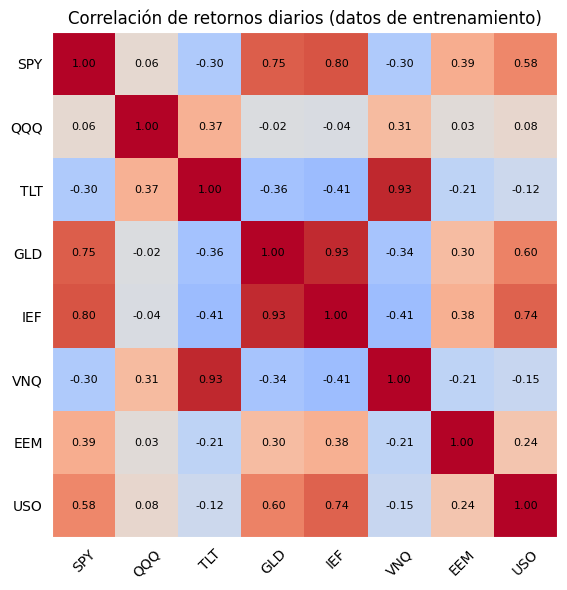


Pares con correlación > 0.90:
TLT ↔ VNQ: 0.930
GLD ↔ IEF: 0.927


In [88]:
ret_train = np.log(prices_train / prices_train.shift(1)).dropna()
corr      = ret_train.corr()

fig, ax = plt.subplots(figsize=(8, 6), facecolor="#FFFFFF")
ax.set_facecolor('#1A1D27')
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, rotation=45, color='black')
ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS, color='black')
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center', fontsize=8,
                color='black' if abs(corr.values[i,j]) > 0.5 else 'black')

ax.set_title('Correlación de retornos diarios (datos de entrenamiento)', color='black')
plt.tight_layout()
plt.savefig('results/correlacion.png', dpi=150, bbox_inches='tight', facecolor='#FFFFFF')
plt.show()

# Alertar pares muy correlacionados
print('\nPares con correlación > 0.90:')
for i in range(len(TICKERS)):
    for j in range(i+1, len(TICKERS)):
        if abs(corr.values[i,j]) > 0.90:
            print(f'{TICKERS[i]} ↔ {TICKERS[j]}: {corr.values[i,j]:.3f}')

In [ ]:
# ── Análisis de regímenes de mercado ─────────────────────────────────────────
# Verifica que el train incluye distintos regímenes (alcista, bajista, lateral).
# Si el agente solo ve bull markets en train, no aprende a protegerse en caídas.
print('Retorno anual medio de la cartera EW por año:')
for year in sorted(ret_train.index.year.unique()):
    r = ret_train[ret_train.index.year == year].mean(axis=1)
    ret_anual = r.mean() * 252 * 100
    vol_anual = r.std()  * np.sqrt(252) * 100
    regime    = '🔴 bajista' if ret_anual < -5 else ('🟡 lateral' if ret_anual < 8 else '🟢 alcista')
    print(f'  {year}: {ret_anual:+6.1f}%  vol={vol_anual:.1f}%  {regime}')

Retorno anual medio de la cartera EW por año:
  2014:   +4.4%  vol=6.6%  🟡 lateral
  2015:   -9.8%  vol=10.5%  🔴 bajista
  2016:   +6.6%  vol=10.3%  🟡 lateral
  2017:  +13.8%  vol=5.9%  🟢 alcista
  2018:   -6.5%  vol=10.2%  🔴 bajista
  2019:  +21.0%  vol=7.5%  🟢 alcista
  2020:   +0.3%  vol=22.0%  🟡 lateral


## 2. Entornos

In [ ]:
ENV_KWARGS = dict(
    transaction_cost      = 0.0005,  
    turnover_penalty      = 0.001,
    episode_length        = 252,
)

env_train = PortfolioEnvBBVA(prices_train, **ENV_KWARGS)
env_val   = PortfolioEnvBBVA(prices_val,   **ENV_KWARGS)
env_test  = PortfolioEnvBBVA(prices_test,  **ENV_KWARGS)

obs_dim = env_train.observation_space.shape[0]
act_dim = env_train.n
print(f'obs_dim={obs_dim}, act_dim={act_dim}')

obs_dim=64, act_dim=8


## 3. Entrenamiento con early stopping

In [ ]:
agent = PPOAgent(obs_dim, act_dim, lr=1e-4, clip=0.15, n_steps=256)
history = agent.train(env_train, env_val, epochs=200, patience=8, save_path='models/ppo')

Epoch  10/200 | val_return=+0.1005 | best=+0.1005 | pl=-0.0032 vl=2051.9250
Epoch  20/200 | val_return=+0.1003 | best=+0.1005 | pl=-0.0023 vl=832.5863
Epoch  30/200 | val_return=+0.1005 | best=+0.1005 | pl=-0.0028 vl=989.7105
Epoch  40/200 | val_return=+0.1001 | best=+0.1005 | pl=-0.0012 vl=1881.7169
Epoch  50/200 | val_return=+0.1006 | best=+0.1006 | pl=-0.0023 vl=933.2242
Epoch  60/200 | val_return=+0.1017 | best=+0.1017 | pl=-0.0022 vl=1649.3022
Epoch  70/200 | val_return=+0.1016 | best=+0.1017 | pl=-0.0046 vl=490.8802
Epoch  80/200 | val_return=+0.1011 | best=+0.1017 | pl=-0.0028 vl=1246.9668
Epoch  90/200 | val_return=+0.0993 | best=+0.1017 | pl=-0.0044 vl=525.0032
Epoch 100/200 | val_return=+0.0979 | best=+0.1017 | pl=-0.0041 vl=884.5270
Epoch 110/200 | val_return=+0.0978 | best=+0.1017 | pl=-0.0021 vl=1013.3718
Epoch 120/200 | val_return=+0.0960 | best=+0.1017 | pl=-0.0043 vl=750.2999
Epoch 130/200 | val_return=+0.0969 | best=+0.1017 | pl=-0.0039 vl=398.4293

  Early stopping en

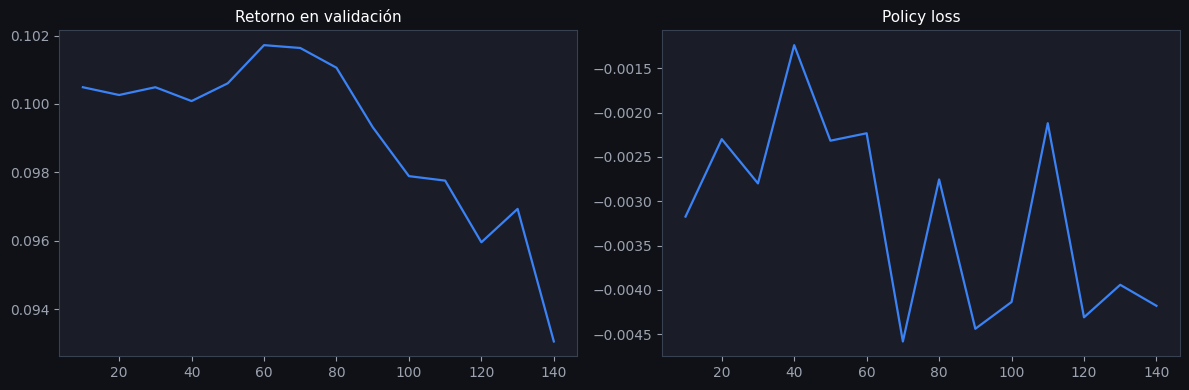

In [ ]:
# Curva de aprendizaje
df_h = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0F1117')
for ax, col, title in zip(axes, ['val_return','policy_loss'], ['Retorno en validación','Policy loss']):
    ax.set_facecolor('#1A1D27')
    ax.plot(df_h['epoch'], df_h[col], color='#3B82F6', linewidth=1.6)
    ax.set_title(title, color='white', fontsize=11)
    ax.tick_params(colors='#9CA3AF')
    for spine in ax.spines.values(): spine.set_color('#374151')
plt.tight_layout()
plt.savefig('results/curva_aprendizaje.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 4. Métricas completas — función de evaluación

In [ ]:
def metrics_completas(values):
    """Calcula todas las métricas estándar de gestión de carteras."""
    dr   = np.diff(values) / values[:-1]
    rf_d    = (1 + 0.05) ** (1/252) - 1
    excess_dr = dr - rf_d
    peak = np.maximum.accumulate(values)
    dd   = (values - peak) / peak
    T    = len(dr)
    yrs  = T / 252
    neg  = dr[dr < 0]

    cagr    = (values[-1]/values[0])**(1/yrs) - 1 if yrs > 0 else 0
    vol     = dr.std() * np.sqrt(252)
    sharpe  = excess_dr.mean() / (excess_dr.std() + 1e-9) * np.sqrt(252)
    sortino = excess_dr.mean() / (neg.std() + 1e-9) * np.sqrt(252) if len(neg) > 1 else np.nan
    max_dd  = dd.min()
    calmar  = cagr / abs(max_dd) if max_dd != 0 else np.nan
    var95   = np.percentile(dr, 5)  # pérdida en el peor 5% de días

    return {
        'Retorno total (%)':  round(float(values[-1]-1)*100, 2),
        'CAGR (%)':           round(cagr*100, 2),
        'Volatilidad (%)':    round(vol*100, 2),
        'Sharpe':             round(sharpe, 3),
        'Sortino':            round(sortino, 3),
        'Max Drawdown (%)':   round(max_dd*100, 2),
        'Calmar':             round(calmar, 3),
        'VaR 95% (%)':        round(var95*100, 3),
    }

def run_fixed(env, weights, tc=0.001):
    """Ejecuta pesos fijos (EW o Buy&Hold) desde el inicio del dataset de test."""
    env    = PortfolioEnvBBVA(prices_test, transaction_cost=tc,
                               turnover_penalty=0, episode_length=252)
    logits = np.log(np.array(weights, dtype=np.float32) + 1e-9)
    env._t = env._t_start = 50
    env._weights = np.array(weights, dtype=np.float32)
    env._value   = 1.0
    env._returns = []
    obs = env._obs()
    values, done = [1.0], False
    while not done:
        obs, _, term, trunc, info = env.step(logits)
        values.append(info['value'])
        done = term or trunc
    return np.array(values)

## 5. Evaluación out-of-sample y tabla comparativa

In [ ]:
n    = len(TICKERS)
w_ew = np.array([1/n] * n)


w_spy          = np.zeros(n)
w_spy[TICKERS.index('SPY')] = 1.0

# PPO
ppo_values, ppo_weights = agent.evaluate_on_env(env_test)

# Baselines
ew_values  = run_fixed(prices_test, w_ew,  tc=0.001)
bh_values  = run_fixed(prices_test, w_ew,  tc=0.0)
spy_values = run_fixed(prices_test, w_spy, tc=0.001)

# Markowitz (requiere: pip install pyportfolioopt)
from pypfopt import EfficientFrontier, expected_returns, risk_models
mu    = expected_returns.mean_historical_return(prices_train)
sigma = risk_models.sample_cov(prices_train)
ef    = EfficientFrontier(mu, sigma,weight_bounds=(0.00, 0.4))
ef.max_sharpe()
w_mvo    = np.array([ef.clean_weights().get(t,0.) for t in TICKERS], dtype=np.float32)
mvo_vals = run_fixed(prices_test, w_mvo, tc=0.001)
print(f'Pesos Markowitz: {dict(zip(TICKERS, w_mvo.round(3)))}')

results = {
    'PPO (TFM)':        ppo_values,
    'Equally Weighted': ew_values,
    'Buy & Hold':       bh_values,
    'SPY 100%':         spy_values,
    'Markowitz MVO':    mvo_vals,   
}

df_metrics = pd.DataFrame(
    {k: metrics_completas(v) for k, v in results.items()}
).T
print('\n=== Tabla comparativa — Test 2024 (out-of-sample) ===')
print(df_metrics.to_string())
df_metrics.to_csv('results/metricas_completas.csv')

Pesos Markowitz: {'SPY': np.float32(0.0), 'QQQ': np.float32(0.329), 'TLT': np.float32(0.242), 'GLD': np.float32(0.03), 'IEF': np.float32(0.4), 'VNQ': np.float32(0.0), 'EEM': np.float32(0.0), 'USO': np.float32(0.0)}

=== Tabla comparativa — Test 2024 (out-of-sample) ===
                  Retorno total (%)  CAGR (%)  Volatilidad (%)  Sharpe  Sortino  Max Drawdown (%)  Calmar  VaR 95% (%)
PPO (TFM)                     15.48     15.48             9.29   1.071    1.958             -7.70   2.012       -0.862
Equally Weighted              15.55     15.55             9.30   1.076    1.950             -7.66   2.028       -0.861
Buy & Hold                    15.74     15.74             9.30   1.094    1.982             -7.63   2.063       -0.861
SPY 100%                      10.83     10.83            14.64   0.442    0.771            -12.92   0.838       -1.435
Markowitz MVO                 17.02     17.02             7.65   1.456    2.562             -7.27   2.342       -0.685


## 6. Visualizaciones

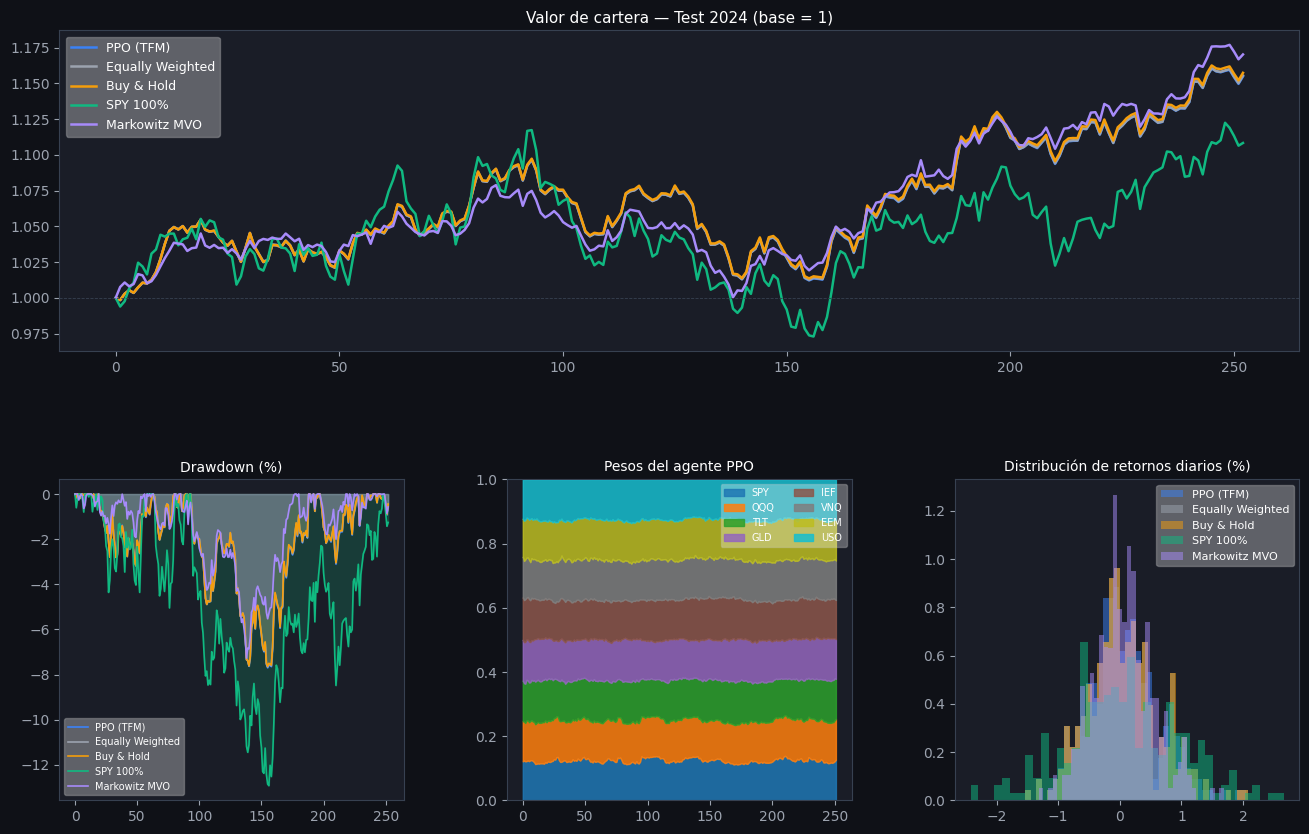

In [ ]:
COLORS = {
    'PPO (TFM)':        '#3B82F6',
    'Equally Weighted': '#9CA3AF',
    'Buy & Hold':       '#F59E0B',
    'SPY 100%':         '#10B981',
    'Markowitz MVO':    '#A78BFA',
}
fig = plt.figure(figsize=(16, 10), facecolor='#0F1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

ax = fig.add_subplot(gs[0, :])
ax.set_facecolor('#1A1D27')
for name, vals in results.items():
    ax.plot(vals/vals[0], label=name, color=COLORS.get(name,'#fff'), linewidth=1.8)
ax.axhline(1, color='#374151', linewidth=0.6, linestyle='--')
ax.set_title('Valor de cartera — Test 2024 (base = 1)', color='white', fontsize=11)
ax.legend(fontsize=9, framealpha=0.3, labelcolor='white')
ax.tick_params(colors='#9CA3AF')
for s in ax.spines.values(): s.set_color('#374151')

ax = fig.add_subplot(gs[1, 0])
ax.set_facecolor('#1A1D27')
for name, vals in results.items():
    peak = np.maximum.accumulate(vals)
    dd   = (vals - peak) / peak * 100
    ax.fill_between(range(len(dd)), dd, 0, alpha=0.2, color=COLORS.get(name,'#fff'))
    ax.plot(dd, color=COLORS.get(name,'#fff'), linewidth=1.2, label=name)
ax.set_title('Drawdown (%)', color='white', fontsize=10)
ax.legend(fontsize=7, framealpha=0.3, labelcolor='white')
ax.tick_params(colors='#9CA3AF')
for s in ax.spines.values(): s.set_color('#374151')

ax = fig.add_subplot(gs[1, 1])
ax.set_facecolor('#1A1D27')
cmap   = plt.cm.get_cmap('tab10', n)
bottom = np.zeros(len(ppo_weights))
for i, tick in enumerate(TICKERS):
    ax.fill_between(range(len(ppo_weights)), bottom, bottom+ppo_weights[:,i],
                    label=tick, color=cmap(i), alpha=0.85)
    bottom += ppo_weights[:,i]
ax.set_ylim(0, 1)
ax.set_title('Pesos del agente PPO', color='white', fontsize=10)
ax.legend(fontsize=7, framealpha=0.3, labelcolor='white', ncol=2)
ax.tick_params(colors='#9CA3AF')
for s in ax.spines.values(): s.set_color('#374151')

ax = fig.add_subplot(gs[1, 2])
ax.set_facecolor('#1A1D27')
for name, vals in results.items():
    dr = np.diff(vals)/vals[:-1]*100
    ax.hist(dr, bins=40, alpha=0.5, label=name, color=COLORS.get(name,'#fff'), density=True)
ax.set_title('Distribución de retornos diarios (%)', color='white', fontsize=10)
ax.legend(fontsize=8, framealpha=0.3, labelcolor='white')
ax.tick_params(colors='#9CA3AF')
for s in ax.spines.values(): s.set_color('#374151')

plt.savefig('results/comparativa_completa.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 7. Análisis de sensibilidad de costes

Sensibilidad del agente PPO a los costes de transacción:
    1 bps → retorno=+15.66%  Sharpe=+1.087
    5 bps → retorno=+15.48%  Sharpe=+1.071
   10 bps → retorno=+15.27%  Sharpe=+1.051
   20 bps → retorno=+14.84%  Sharpe=+1.011
   50 bps → retorno=+13.57%  Sharpe=+0.891


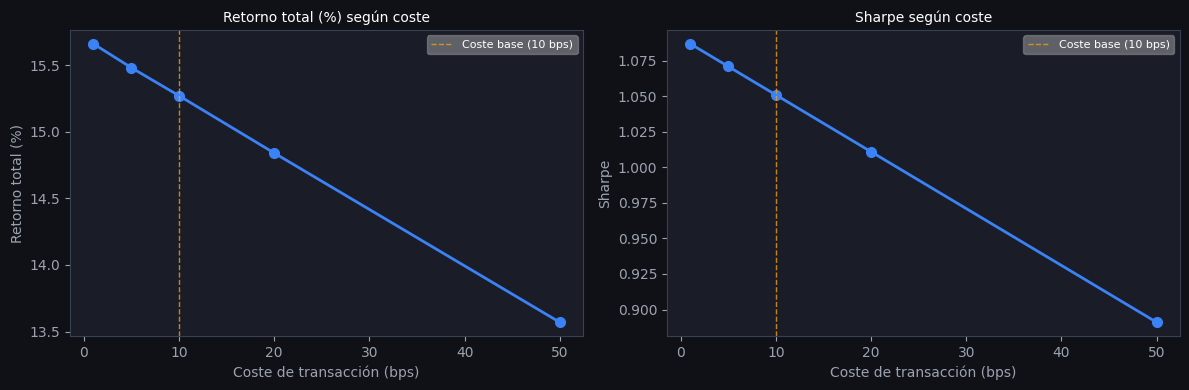

In [ ]:
costes_bps = [1, 5, 10, 20, 50]           # en basis points
costes_dec = [c / 10_000 for c in costes_bps]
retornos, sharpes = [], []

print('Sensibilidad del agente PPO a los costes de transacción:')
for tc, bps in zip(costes_dec, costes_bps):
    env_tc = PortfolioEnvBBVA(prices_test, transaction_cost=tc,
                               turnover_penalty=0, episode_length=252)
    vals, _ = agent.evaluate_on_env(env_tc)
    m = metrics_completas(vals)
    retornos.append(m['Retorno total (%)'])
    sharpes.append(m['Sharpe'])
    print(f'  {bps:3d} bps → retorno={m["Retorno total (%)"]:+.2f}%  Sharpe={m["Sharpe"]:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0F1117')
for ax, data, title, ylabel in zip(axes,
    [retornos, sharpes],
    ['Retorno total (%) según coste', 'Sharpe según coste'],
    ['Retorno total (%)', 'Sharpe']):
    ax.set_facecolor('#1A1D27')
    ax.plot(costes_bps, data, color='#3B82F6', marker='o', linewidth=2, markersize=7)
    ax.axvline(10, color='#F59E0B', lw=1, ls='--', alpha=0.8, label='Coste base (10 bps)')
    ax.set_title(title, color='white', fontsize=10)
    ax.set_xlabel('Coste de transacción (bps)', color='#9CA3AF')
    ax.set_ylabel(ylabel, color='#9CA3AF')
    ax.legend(fontsize=8, framealpha=0.3, labelcolor='white')
    ax.tick_params(colors='#9CA3AF')
    for s in ax.spines.values(): s.set_color('#374151')

plt.tight_layout()
plt.savefig('results/sensibilidad_costes.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()